In [39]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [ ]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [7]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [8]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [9]:
train_df = pd.read_csv(f"{DATASET_DIR}/train.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val.csv")

In [10]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [12]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # transforms.RandomHorizontalFlip(),  # randomly flip images horizontally
    # transforms.RandomRotation(10),      # slight random rotation
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # random translation
    transforms.ToTensor(),
    # transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

# Keep validation transforms simple - just basic preprocessing
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    # transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)

In [13]:
from torch.utils.data import WeightedRandomSampler

labels = train_df_encoded["Label"].values
class_weights = 1 / np.bincount(labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [14]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [ ]:
class BasicSNN(nn.Module):
    def __init__(self, beta=0.5, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(16)  # Add batch norm
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad)

        self.conv2 = nn.Conv2d(16, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)  # Add batch norm
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad)

        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.bn3 = nn.BatchNorm1d(64)  # Add batch norm
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad)

        self.fc2 = nn.Linear(64, self.num_classes)
        self.lif4 = snn.Leaky(beta=beta, spike_grad=self.spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.num_steps):
            cur1 = F.max_pool2d(self.conv1(x), 2)  # Remove F.relu
            mem1, spike1 = self.lif1(cur1, mem1)

            cur2 = F.max_pool2d(self.conv2(spike1), 2)  # Remove F.relu
            mem2, spike2 = self.lif2(cur2, mem2)

            flatten = spike2.flatten(1)

            cur3 = self.fc1(flatten)  # Remove F.relu
            mem3, spike3 = self.lif3(cur3, mem3)

            cur4 = self.fc2(spike3)
            mem4, spike4 = self.lif4(cur4, mem4)

            spk_rec.append(spike4)
            mem_rec.append(mem4)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)
    
    def reset_states(self):
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif3.reset_mem()
        self.lif4.reset_mem()
        



In [83]:
data, target = next(iter(train_data_loader))
data.size(0)

40

In [ ]:
# def train_model(train_loader, val_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, eval_freq=50, weights=None, model_savepath=None, device="cuda"):
#     model = BasicSNN(num_steps=8).to(device)


#     if weight_decay:
#         optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
#     else:
#         optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

#     train_loss_hist = []
#     val_loss_hist = []
#     acc_hist = []

#     best_val_acc = 0
#     eval_counter = 0

#     for epoch in range(num_epochs):
#         # training
        
#         print(f"Epoch {epoch+1}/{num_epochs}")
#         print("-" * 50)

#         for data, targets in tqdm(train_loader, desc=f"Training"):
#             data, targets = data.to(device), targets.to(device)

#             model.train()
#             model.reset_states()

#             # forward pass
#             spk_rec, _ = model(data)

#             # calculate loss
#             loss = loss_fn(spk_rec, targets)

#             # zero gradients
#             optimizer.zero_grad()

#             # backward pass
#             loss.backward()

#             # update weights
#             optimizer.step()

#             train_loss_hist.append(loss.item())

#         # validation
#         with torch.no_grad():
#             model.eval()

#             correct = 0
#             total = 0

#             for data, targets in tqdm(val_loader, desc=f"Validation"):
#                 data, targets = data.to(device), targets.to(device)

#                 model.reset_states()

#                 spk_rec, _ = model(data)

#                 # calculate loss
#                 loss = loss_fn(spk_rec, targets)
#                 acc = SF.accuracy_rate(spk_rec, targets)

#                 correct += acc * data.size(0)
#                 total += data.size(0)

#                 val_loss_hist.append(loss.item())

#             # calculate accuracy
#             val_acc = correct / total
#             acc_hist.append(val_acc)
            
#             if val_acc > best_val_acc:
#                 best_val_acc = val_acc
#                 if model_savepath:
#                     torch.save(model.state_dict(), model_savepath)
#                     print(f"Model saved at {model_savepath}")

#             print(f"Validation Loss: {loss.item():.4f}, Validation Accuracy: {val_acc:.4f}")
#             print("-" * 50)

#     history = {
#         "train_loss": train_loss_hist,
#         "val_loss": val_loss_hist,
#         "val_acc": acc_hist
#     }

#     return model, history

def calculate_accuracy(model, data_loader, device="cuda"):
    correct = 0
    total = 0

    for data, targets in tqdm(data_loader, desc="Calculating Accuracy"):
        data, targets = data.to(device), targets.to(device)

        model.reset_states()

        spk_rec, _ = model(data)

        # calculate accuracy
        acc = SF.accuracy_rate(spk_rec, targets)

        correct += acc * data.size(0)
        total += data.size(0)

    return correct / total


def train_model(train_loader, val_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", plot_results=True):
    
    model = BasicSNN(num_steps=4).to(device)

    if weight_decay:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    # Initialize tracking lists
    train_loss_hist = []
    val_loss_hist = []
    acc_hist = []
    spike_stats = {
        'avg_spikes_per_neuron': [],
        'spike_count': [],
        'active_neurons_percent': [],
        'firing_rate_stability': [],
        'membrane_potential_avg': [],
        'membrane_potential_std': []
    }

    # For statistical tracking only
    best_val_acc = 0
    best_epoch = 0
    prev_firing_rates = None

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)
        
        epoch_train_loss = 0
        epoch_train_batches = 0
        epoch_spike_count = 0
        epoch_active_neurons = 0
        total_neurons = 0
        epoch_membrane_sum = 0
        epoch_membrane_samples = 0
        epoch_membrane_std_sum = 0
        

        # Training loop
        for data, targets in tqdm(train_loader, desc=f"Training"):
            data, targets = data.to(device), targets.to(device)

            model.train()
            utils.reset(model)  # Reset states using utils.reset

            # Forward pass with spike recording
            spk_rec, mem_rec = model(data)

            # Get spike statistics
            spike_tensor = spk_rec.detach()  # Shape: [time_steps, batch_size, num_neurons]
            batch_size = spike_tensor.size(1)
            time_steps = spike_tensor.size(0)
            num_neurons = spike_tensor.size(2)
            
            # Count total spikes in this batch
            batch_spike_count = torch.sum(spike_tensor).item()
            epoch_spike_count += batch_spike_count
            
            # Count active neurons (neurons that spike at least once)
            active_neurons = torch.sum(torch.sum(spike_tensor, dim=1) > 0).item()
            epoch_active_neurons += active_neurons
            total_neurons += batch_size * num_neurons
            
            # Membrane potential statistics if available
            if mem_rec is not None:
                mem_tensor = mem_rec.detach()
                epoch_membrane_sum += torch.mean(mem_tensor).item() * batch_size * time_steps * num_neurons
                epoch_membrane_std_sum += torch.std(mem_tensor).item() * batch_size * time_steps * num_neurons
                epoch_membrane_samples += batch_size * time_steps * num_neurons

            # Calculate loss
            loss = loss_fn(spk_rec, targets)
            epoch_train_loss += loss.item()
            epoch_train_batches += 1

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Calculate average training loss for this epoch
        avg_epoch_train_loss = epoch_train_loss / epoch_train_batches
        train_loss_hist.append(avg_epoch_train_loss)

        # Calculate spike statistics for the epoch
        avg_spikes_per_neuron = epoch_spike_count / (total_neurons * time_steps)
        active_neurons_percent = (epoch_active_neurons / total_neurons) * 100
        
        # Calculate membrane potential statistics
        if epoch_membrane_samples > 0:
            avg_membrane = epoch_membrane_sum / epoch_membrane_samples
            std_membrane = epoch_membrane_std_sum / epoch_membrane_samples
        else:
            avg_membrane = 0
            std_membrane = 0
        
        # Store training statistics
        spike_stats['avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        spike_stats['spike_count'].append(epoch_spike_count)
        spike_stats['active_neurons_percent'].append(active_neurons_percent)
        spike_stats['membrane_potential_avg'].append(avg_membrane)
        spike_stats['membrane_potential_std'].append(std_membrane)
        
        print(f"Training Loss: {avg_epoch_train_loss:.4f}")
        print(f"Avg Spikes per Neuron: {avg_spikes_per_neuron:.4f}")
        print(f"Active Neurons: {active_neurons_percent:.2f}%")
        print(f"Avg Membrane Potential: {avg_membrane:.4f}")

        # Validation
        with torch.no_grad():
            model.eval()
            val_loss = 0
            val_batches = 0
            correct = 0
            total = 0
            val_spike_count = 0
            val_total_neurons = 0
            firing_rates = []

            for data, targets in tqdm(val_loader, desc=f"Validation"):
                data, targets = data.to(device), targets.to(device)

                utils.reset(model)  # Reset states using utils.reset
                spk_rec, mem_rec = model(data)

                # Get spike statistics for validation
                spike_tensor = spk_rec.detach()
                batch_size = spike_tensor.size(1)
                time_steps = spike_tensor.size(0)
                num_neurons = spike_tensor.size(2)
                
                # Firing rates per neuron (averaged over batch and time)
                batch_firing_rates = torch.mean(spike_tensor, dim=(0, 1)).cpu().numpy()
                firing_rates.append(batch_firing_rates)
                
                # Count spikes
                val_spike_count += torch.sum(spike_tensor).item()
                val_total_neurons += batch_size * num_neurons

                # Calculate validation metrics
                loss = loss_fn(spk_rec, targets)
                acc = SF.accuracy_rate(spk_rec, targets)

                val_loss += loss.item()
                val_batches += 1
                correct += acc * data.size(0)
                total += data.size(0)

            # Calculate average validation metrics
            avg_val_loss = val_loss / val_batches
            val_loss_hist.append(avg_val_loss)
            
            val_acc = correct / total
            acc_hist.append(val_acc)
            
            # Calculate validation spike rate
            val_avg_spikes_per_neuron = val_spike_count / (val_total_neurons * time_steps)
            
            # Calculate firing rate stability (consistency between epochs)
            avg_firing_rates = np.mean(np.vstack(firing_rates), axis=0)
            
            firing_rate_stability = 0
            if epoch > 0 and prev_firing_rates is not None:
                # Correlation between current and previous firing rates
                firing_rate_stability = np.corrcoef(avg_firing_rates, prev_firing_rates)[0, 1]
                if np.isnan(firing_rate_stability):
                    firing_rate_stability = 0
            
            prev_firing_rates = avg_firing_rates
            spike_stats['firing_rate_stability'].append(firing_rate_stability)
            
            print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")
            print(f"Validation Avg Spikes per Neuron: {val_avg_spikes_per_neuron:.4f}")
            print(f"Firing Rate Stability: {firing_rate_stability:.4f}")
            
            # Just track best accuracy for stats (no model saving)
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
            
            print("-" * 50)

        # Update learning rate scheduler
        scheduler.step(avg_val_loss)

    # Save model at the end of training
    if model_savepath:
        torch.save(model.state_dict(), model_savepath)
        print(f"Final model saved at {model_savepath} after {num_epochs} epochs")

    # Plotting results if requested
    if plot_results:
        plot_training_results(train_loss_hist, val_loss_hist, acc_hist, spike_stats)

    # Return model and all training history
    history = {
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "val_acc": acc_hist,
        "spike_stats": spike_stats,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "final_val_acc": val_acc
    }

    return model, history

def plot_training_results(train_loss, val_loss, val_acc, spike_stats):
    """Plot training results including loss curves and spike statistics."""
    plt.figure(figsize=(18, 15))
    
    # Plot training and validation loss
    plt.subplot(3, 2, 1)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot validation accuracy
    plt.subplot(3, 2, 2)
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Plot average spikes per neuron
    plt.subplot(3, 2, 3)
    plt.plot(spike_stats['avg_spikes_per_neuron'], label='Avg Spikes per Neuron')
    plt.title('Average Spikes per Neuron')
    plt.xlabel('Epochs')
    plt.ylabel('Spikes')
    plt.legend()
    plt.grid(True)
    
    # Plot active neurons percentage
    plt.subplot(3, 2, 4)
    plt.plot(spike_stats['active_neurons_percent'], label='Active Neurons (%)')
    plt.title('Percentage of Active Neurons')
    plt.xlabel('Epochs')
    plt.ylabel('Percentage (%)')
    plt.legend()
    plt.grid(True)
    
    # Plot firing rate stability
    plt.subplot(3, 2, 5)
    plt.plot(spike_stats['firing_rate_stability'], label='Firing Rate Stability')
    plt.title('Firing Rate Stability Between Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Stability (Correlation)')
    plt.legend()
    plt.grid(True)
    
    # Plot membrane potential statistics
    plt.subplot(3, 2, 6)
    plt.plot(spike_stats['membrane_potential_avg'], label='Avg Membrane Potential')
    plt.fill_between(
        range(len(spike_stats['membrane_potential_avg'])),
        [a - s for a, s in zip(spike_stats['membrane_potential_avg'], spike_stats['membrane_potential_std'])],
        [a + s for a, s in zip(spike_stats['membrane_potential_avg'], spike_stats['membrane_potential_std'])],
        alpha=0.3
    )
    plt.title('Membrane Potential Statistics')
    plt.xlabel('Epochs')
    plt.ylabel('Potential')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


def analyze_spike_patterns(model, loader, device="cuda", num_samples=5):
    """Analyze spike patterns for a few samples to get deeper insights."""
    
    
    samples_analyzed = 0
    spike_patterns = []
    
    plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        model.eval()
        
        for data, targets in loader:
            if samples_analyzed >= num_samples:
                break
                
            data, targets = data.to(device), targets.to(device)
            
            model.reset_states()
            spk_rec, mem_rec = model(data)
            
            # Get first sample from batch
            sample_spikes = spk_rec[0].cpu().numpy()  # [time_steps, neurons]
            if mem_rec is not None:
                sample_mem = mem_rec[0].cpu().numpy()
            else:
                sample_mem = None
                
            # Plot spike raster
            plt.subplot(num_samples, 2, samples_analyzed * 2 + 1)
            for n in range(sample_spikes.shape[1]):
                spike_times = np.where(sample_spikes[:, n] > 0)[0]
                if len(spike_times) > 0:
                    plt.scatter(spike_times, [n] * len(spike_times), marker='|', color='black', s=50)
            
            plt.title(f"Sample {samples_analyzed+1} - Target: {targets[0].item()}")
            plt.xlabel("Time Step")
            plt.ylabel("Neuron Index")
            plt.xlim(0, sample_spikes.shape[0])
            plt.ylim(0, sample_spikes.shape[1])
            
            # Plot membrane potential if available
            if sample_mem is not None:
                plt.subplot(num_samples, 2, samples_analyzed * 2 + 2)
                plt.imshow(sample_mem.T, aspect='auto', cmap='viridis')
                plt.colorbar(label='Membrane Potential')
                plt.title(f"Sample {samples_analyzed+1} - Membrane Potential")
                plt.xlabel("Time Step")
                plt.ylabel("Neuron Index")
            
            # Store stats
            spike_patterns.append({
                'target': targets[0].item(),
                'total_spikes': np.sum(sample_spikes),
                'active_neurons': np.sum(np.sum(sample_spikes, axis=0) > 0),
                'spike_pattern': sample_spikes
            })
            
            samples_analyzed += 1
    
    plt.tight_layout()
    plt.show()
    
    return spike_patterns

In [59]:
savepath = f"../models/checkpoints/basic_snn3.cleaned.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)


In [ ]:
loss_fn = SF.ce_rate_loss(weight=class_weights, num_classes=len(LE.classes_))

In [61]:
model, history = train_model(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, plot_results=False)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:29<00:00, 25.36it/s]


Training Loss: 0.3069
Avg Spikes per Neuron: 0.6629
Active Neurons: 8.44%
Avg Membrane Potential: 0.4444


Validation: 100%|██████████| 750/750 [00:25<00:00, 29.70it/s]


Validation Loss: 0.3053, Validation Accuracy: 0.8389
Validation Avg Spikes per Neuron: 0.6714
Firing Rate Stability: 0.0000
--------------------------------------------------
Epoch 2/50
--------------------------------------------------


...

Validation Loss: 0.6130, Validation Accuracy: 0.8789
Validation Avg Spikes per Neuron: 1.0738
Firing Rate Stability: 1.0000
--------------------------------------------------
Epoch 50/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:31<00:00, 24.17it/s]


Training Loss: 0.1141
Avg Spikes per Neuron: 0.8185
Active Neurons: 6.17%
Avg Membrane Potential: 0.4793


Validation: 100%|██████████| 750/750 [00:26<00:00, 28.84it/s]

Validation Loss: 0.5910, Validation Accuracy: 0.8791
Validation Avg Spikes per Neuron: 1.0311
Firing Rate Stability: 1.0000
--------------------------------------------------
Final model saved at ../models/checkpoints/basic_snn3.cleaned.pth after 50 epochs


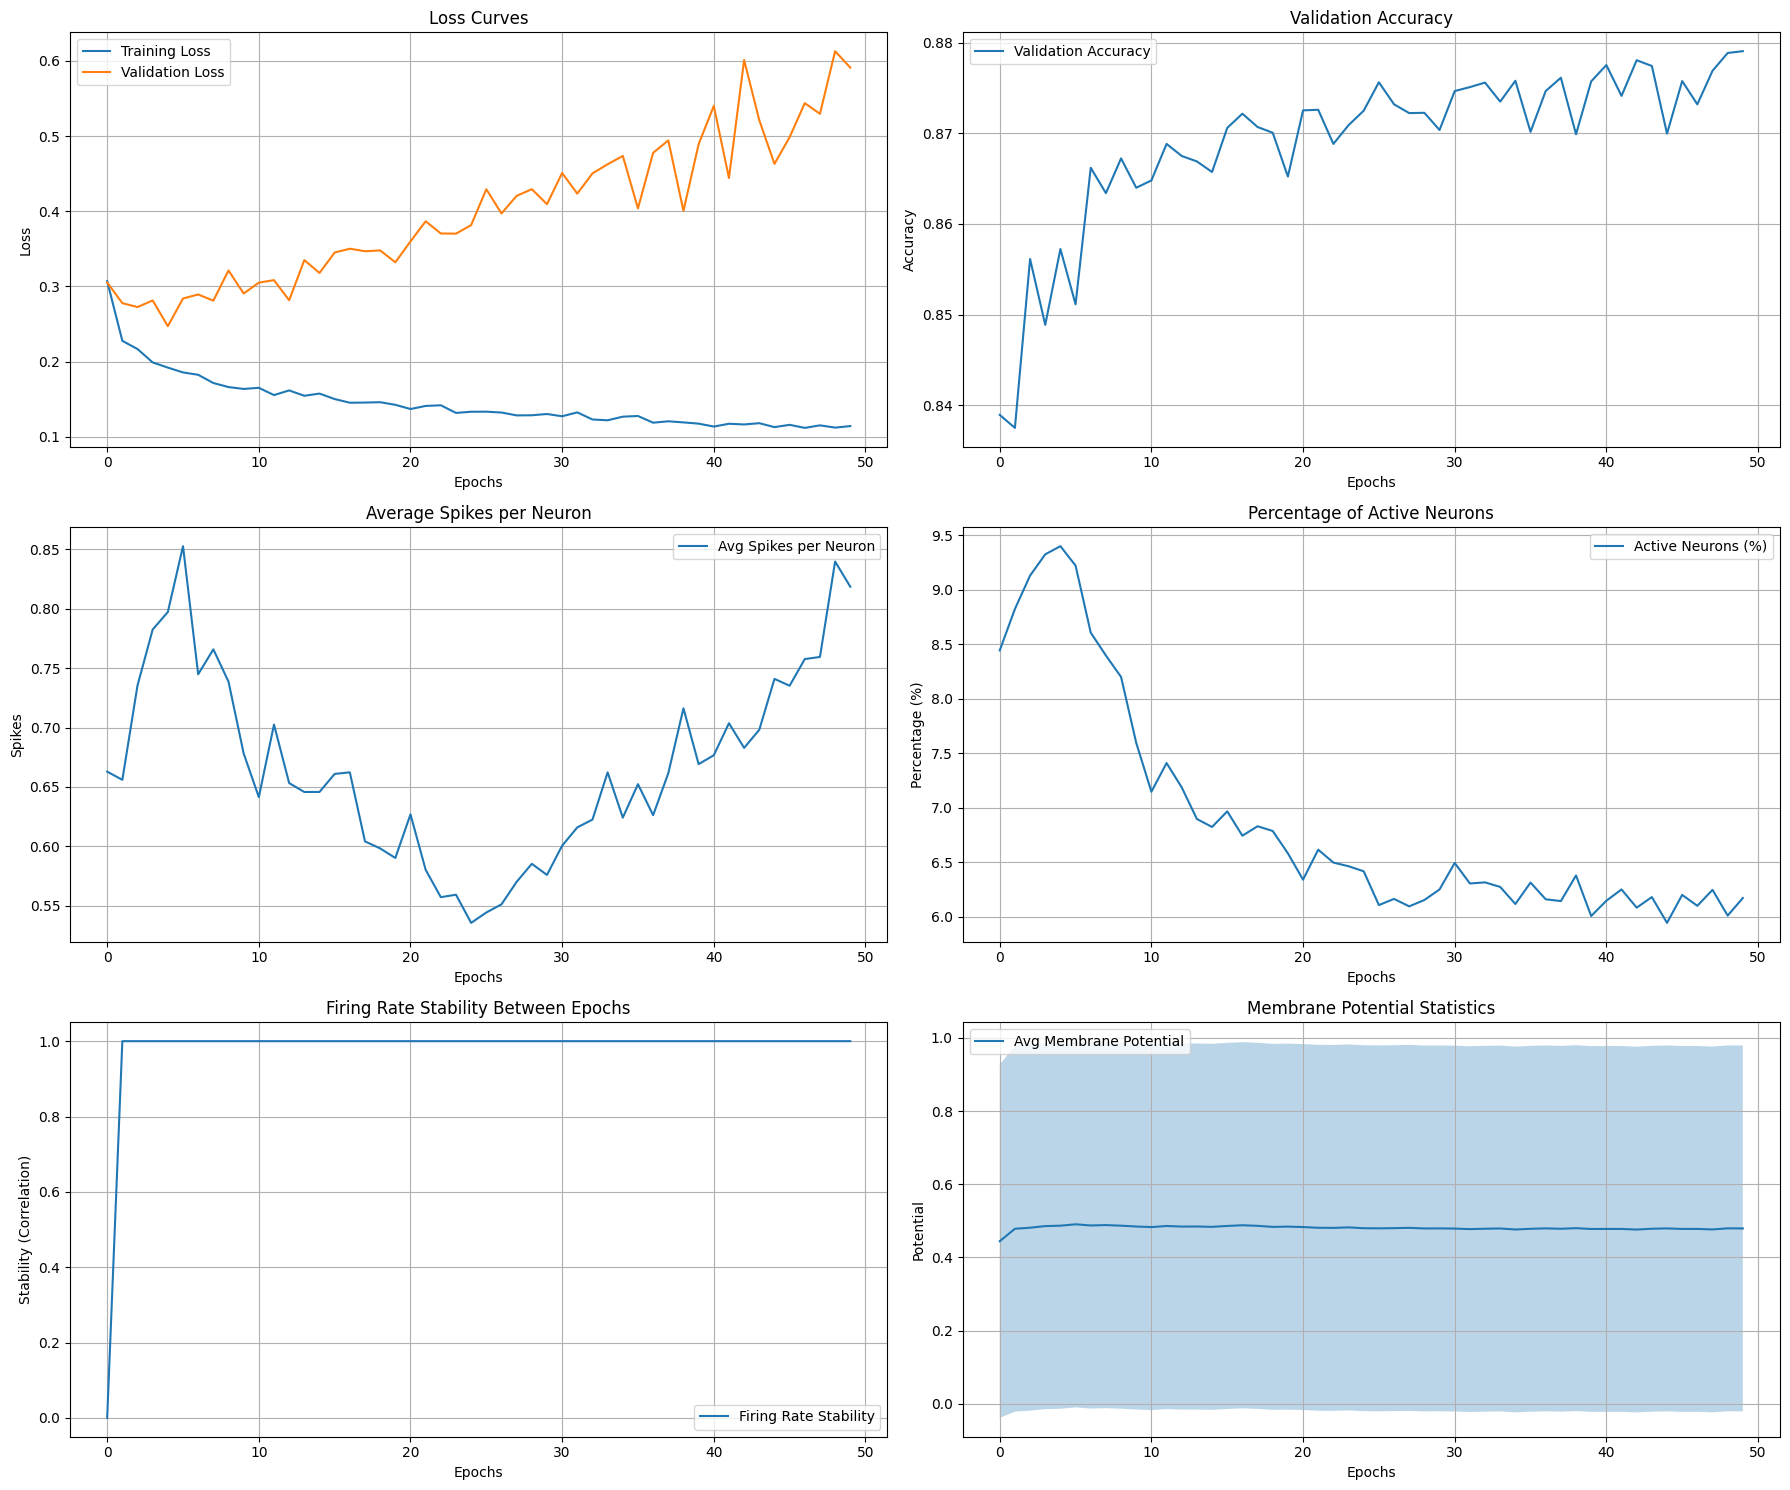

In [69]:
plot_training_results(history["train_loss"], history["val_loss"], history["val_acc"], history["spike_stats"])

In [84]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [85]:
best_model = BasicSNN().to(device)
best_model.load_state_dict(torch.load(savepath, weights_only=True))

<All keys matched successfully>

In [86]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(5000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [89]:
def calculate_accuracy(model):
    y_true = []
    y_pred = []

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in test_data_loader_sample:
            images, labels = images.to(device), labels.to(device)

            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]

            # Aggregate spikes over time (e.g., sum or mean)
            spk_mean = spk_rec.mean(dim=0)  # Shape: [batch_size, num_classes]

            # Get predictions (class with the highest firing rate)
            _, preds = torch.max(spk_mean, dim=1)  # Shape: [batch_size]

            # Store predictions and labels
            y_true.append(labels.cpu().numpy(force=True))  # Avoid unnecessary list flattening
            y_pred.append(preds.cpu().numpy(force=True))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred


# Example usage
y_true, y_pred = calculate_accuracy(best_model)

Accuracy: 0.9280


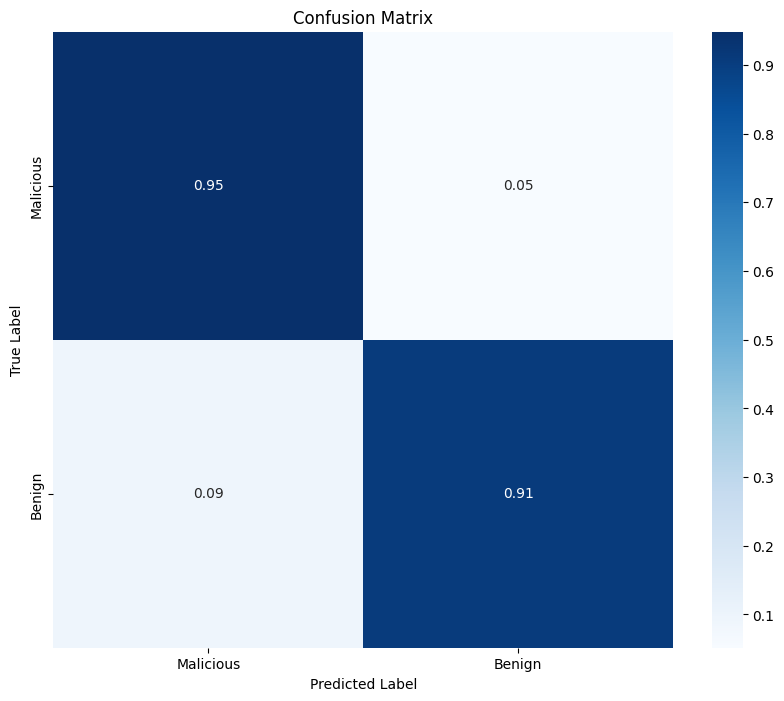

In [92]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    y_true_flatten = np.concatenate(y_true)
    y_pred_flatten = np.concatenate(y_pred)


    cm = confusion_matrix(y_true_flatten, y_pred_flatten, normalize='true', labels=range(len(classes)))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_)